In [41]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt

In [74]:
SIM_ROOT = Path("FINAL_models/Model_A/Model_A_vanilla_val_rollouts_r9.zarr/simulations")

if not SIM_ROOT.exists():
    raise FileNotFoundError(f"Could not find: {SIM_ROOT}")

print("SIM_ROOT =", SIM_ROOT.resolve())

SIM_ROOT = C:\Users\jml2414\Desktop\Spring 2026 Projects\Skin Growth NODE ROM FINAL\FINAL_models\Model_A\Model_A_vanilla_val_rollouts_r9.zarr\simulations


In [75]:
def extract_sim_id(folder_name: str):
    """
    Extract integer simulation id from folder names like:
    sim_00013
    """
    m = re.fullmatch(r"sim_(\d{5})", folder_name)
    return int(m.group(1)) if m else None


def find_arrays_recursive(zobj, prefix=""):
    """
    Return list of (path, array_obj) for all arrays under a zarr object.
    """
    found = []
    if hasattr(zobj, "shape"):
        found.append((prefix if prefix else "<root>", zobj))
        return found

    for key in zobj.keys():
        child = zobj[key]
        child_prefix = f"{prefix}/{key}" if prefix else key
        found.extend(find_arrays_recursive(child, child_prefix))
    return found


def load_single_array_under(node, node_name="node"):
    """
    Load a single array beneath a zarr node.
    """
    arrays = find_arrays_recursive(node)

    if len(arrays) == 0:
        raise RuntimeError(f"No arrays found under {node_name}")
    if len(arrays) > 1:
        print(f"Found multiple arrays under {node_name}:")
        for path, arr in arrays:
            print(f"  {path}: shape={arr.shape}, dtype={arr.dtype}")
        raise RuntimeError(f"Multiple arrays found under {node_name}; choose one explicitly.")

    path, arr = arrays[0]
    return np.asarray(arr)

In [76]:
sim_dirs = sorted([p for p in SIM_ROOT.iterdir() if p.is_dir() and p.name.startswith("sim_")])

print(f"Found {len(sim_dirs)} simulation folders.")
print("First few:")
for p in sim_dirs[:10]:
    print(" ", p.name)

if len(sim_dirs) == 0:
    raise RuntimeError("No sim_* directories found.")

Found 185 simulation folders.
First few:
  sim_00004
  sim_00005
  sim_00007
  sim_00013
  sim_00031
  sim_00035
  sim_00036
  sim_00041
  sim_00048
  sim_00050


In [77]:
records = []
skipped = []

for sim_dir in sim_dirs:
    sim_id = extract_sim_id(sim_dir.name)

    try:
        sim_group = zarr.open_group(str(sim_dir), mode="r")

        if "z_pred" not in sim_group or "z_true" not in sim_group:
            skipped.append((sim_dir.name, "missing z_pred or z_true"))
            continue

        z_pred = load_single_array_under(sim_group["z_pred"], f"{sim_dir.name}/z_pred")
        z_true = load_single_array_under(sim_group["z_true"], f"{sim_dir.name}/z_true")

        if z_pred.shape != z_true.shape:
            skipped.append((sim_dir.name, f"shape mismatch: {z_pred.shape} vs {z_true.shape}"))
            continue

        if z_pred.ndim != 2:
            skipped.append((sim_dir.name, f"expected 2D array, got ndim={z_pred.ndim}"))
            continue

        # Put into shape (T, r_total)
        if z_pred.shape[1] <= z_pred.shape[0]:
            pass
        else:
            z_pred = z_pred.T
            z_true = z_true.T

        T, r_total = z_pred.shape

        if r_total < 2:
            skipped.append((sim_dir.name, f"need at least 2 states to drop last one, got shape {z_pred.shape}"))
            continue

        # Exclude the final state (separate latent/control state)
        z_pred_main = z_pred[:, :-1]
        z_true_main = z_true[:, :-1]

        T, r = z_pred_main.shape

        records.append({
            "sim_id": sim_id,
            "folder": sim_dir.name,
            "T": T,
            "r": r,
            "r_total": r_total,
            "z_pred": z_pred_main,
            "z_true": z_true_main,
            "z_pred_full": z_pred,
            "z_true_full": z_true,
            "err": z_pred_main - z_true_main,
            "abs_err": np.abs(z_pred_main - z_true_main),
            "sq_err": (z_pred_main - z_true_main) ** 2,
        })

    except Exception as e:
        skipped.append((sim_dir.name, str(e)))

print(f"Loaded {len(records)} simulations.")
print(f"Skipped {len(skipped)} simulations.")

if len(skipped) > 0:
    print("\nFirst 15 skipped:")
    for item in skipped[:15]:
        print(item)

if len(records) == 0:
    raise RuntimeError("No simulations were loaded.")

Loaded 185 simulations.
Skipped 0 simulations.


In [78]:
summary_df = pd.DataFrame({
    "sim_id": [rec["sim_id"] for rec in records],
    "folder": [rec["folder"] for rec in records],
    "T": [rec["T"] for rec in records],
    "r": [rec["r"] for rec in records],
}).sort_values("sim_id").reset_index(drop=True)

display(summary_df)

print("Unique latent dimensions found:", sorted(summary_df["r"].unique()))
print("Min rollout length:", summary_df["T"].min())
print("Max rollout length:", summary_df["T"].max())
print("Mean rollout length:", summary_df["T"].mean())

,sim_id,folder,T,r
0,4,sim_00004,31,9
1,5,sim_00005,41,9
2,7,sim_00007,69,9
3,13,sim_00013,69,9
4,31,sim_00031,61,9
...,...,...,...,...
180,911,sim_00911,31,9
181,916,sim_00916,61,9
182,919,sim_00919,31,9
183,921,sim_00921,61,9


Unique latent dimensions found: [np.int64(9)]
Min rollout length: 21
Max rollout length: 69
Mean rollout length: 44.567567567567565


In [79]:
all_err  = np.concatenate([rec["err"] for rec in records], axis=0)
all_true = np.concatenate([rec["z_true"] for rec in records], axis=0)
all_pred = np.concatenate([rec["z_pred"] for rec in records], axis=0)

coef_metrics = pd.DataFrame({
    "coef_idx": np.arange(all_err.shape[1]),
    "MAE": np.mean(np.abs(all_err), axis=0),
    "RMSE": np.sqrt(np.mean(all_err**2, axis=0)),
    "Bias": np.mean(all_err, axis=0),
    "StdErr": np.std(all_err, axis=0),
    "TrueStd": np.std(all_true, axis=0),
    "PredStd": np.std(all_pred, axis=0),
})

coef_metrics["NRMSE_by_true_std"] = coef_metrics["RMSE"] / (coef_metrics["TrueStd"] + 1e-12)
coef_metrics["MAE_by_true_std"]   = coef_metrics["MAE"]  / (coef_metrics["TrueStd"] + 1e-12)

display(coef_metrics)

,coef_idx,MAE,RMSE,Bias,StdErr,TrueStd,PredStd,NRMSE_by_true_std,MAE_by_true_std
0,0,167.880417,199.413864,-167.877686,107.623863,269.190033,175.617035,0.740792,0.623650
1,1,9.438028,17.317768,3.007680,17.054602,47.869682,36.408215,0.361769,0.197161
2,2,6.916138,11.343660,3.602560,10.756401,26.228914,19.566717,0.432487,0.263684
3,3,5.552948,9.031021,-2.871557,8.562344,14.266280,12.702576,0.633033,0.389236
4,4,2.318113,3.631514,2.031482,3.010143,5.920546,4.770797,0.613375,0.391537
5,5,1.318687,2.146942,-0.396911,2.109935,4.823293,4.142541,0.445120,0.273400
6,6,1.683245,2.559863,0.732613,2.452787,3.802117,3.505629,0.673273,0.442713
7,7,1.583133,2.881124,-0.510452,2.835545,3.618961,3.189120,0.796119,0.437455
8,8,0.921844,1.902894,0.504795,1.834718,2.531114,2.205867,0.751801,0.364205


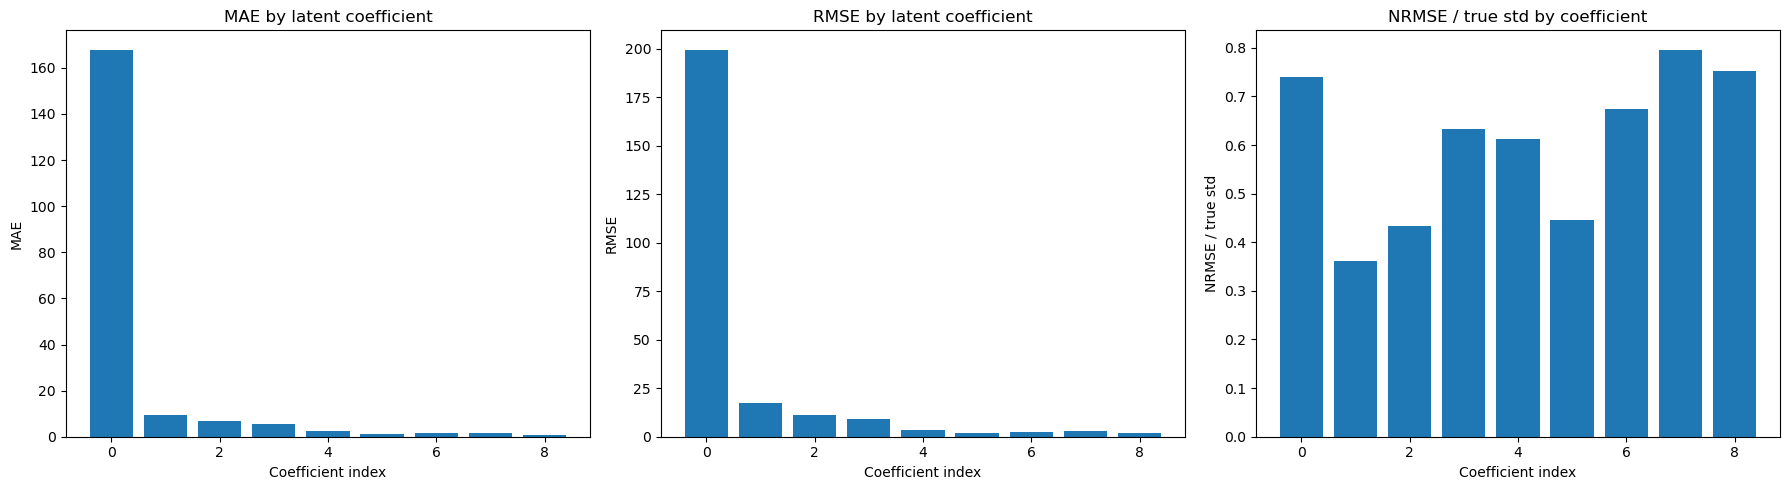

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(coef_metrics["coef_idx"], coef_metrics["MAE"])
axes[0].set_title("MAE by latent coefficient")
axes[0].set_xlabel("Coefficient index")
axes[0].set_ylabel("MAE")

axes[1].bar(coef_metrics["coef_idx"], coef_metrics["RMSE"])
axes[1].set_title("RMSE by latent coefficient")
axes[1].set_xlabel("Coefficient index")
axes[1].set_ylabel("RMSE")

axes[2].bar(coef_metrics["coef_idx"], coef_metrics["NRMSE_by_true_std"])
axes[2].set_title("NRMSE / true std by coefficient")
axes[2].set_xlabel("Coefficient index")
axes[2].set_ylabel("NRMSE / true std")

plt.tight_layout()
plt.show()

In [81]:
max_T = max(rec["T"] for rec in records)
r = records[0]["r"]

mae_t = np.full((max_T, r), np.nan)
rmse_t = np.full((max_T, r), np.nan)
bias_t = np.full((max_T, r), np.nan)
support_t = np.zeros(max_T, dtype=int)

for t in range(max_T):
    errs = []
    for rec in records:
        if rec["T"] > t:
            errs.append(rec["err"][t])

    if len(errs) == 0:
        continue

    errs = np.stack(errs, axis=0)
    support_t[t] = errs.shape[0]
    mae_t[t] = np.mean(np.abs(errs), axis=0)
    rmse_t[t] = np.sqrt(np.mean(errs**2, axis=0))
    bias_t[t] = np.mean(errs, axis=0)

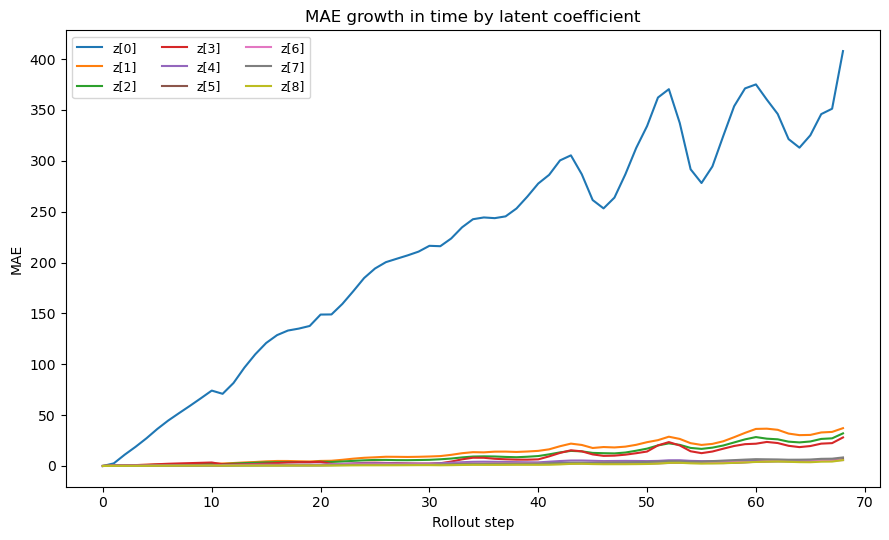

In [82]:
plt.figure(figsize=(9, 5.5))
for k in range(r):
    plt.plot(mae_t[:, k], label=f"z[{k}]")
plt.title("MAE growth in time by latent coefficient")
plt.xlabel("Rollout step")
plt.ylabel("MAE")
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

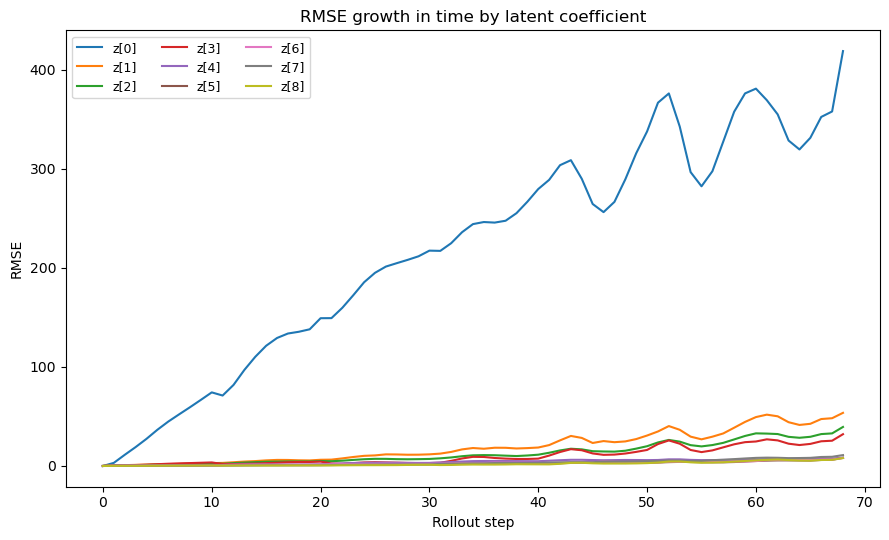

In [83]:
plt.figure(figsize=(9, 5.5))
for k in range(r):
    plt.plot(rmse_t[:, k], label=f"z[{k}]")
plt.title("RMSE growth in time by latent coefficient")
plt.xlabel("Rollout step")
plt.ylabel("RMSE")
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

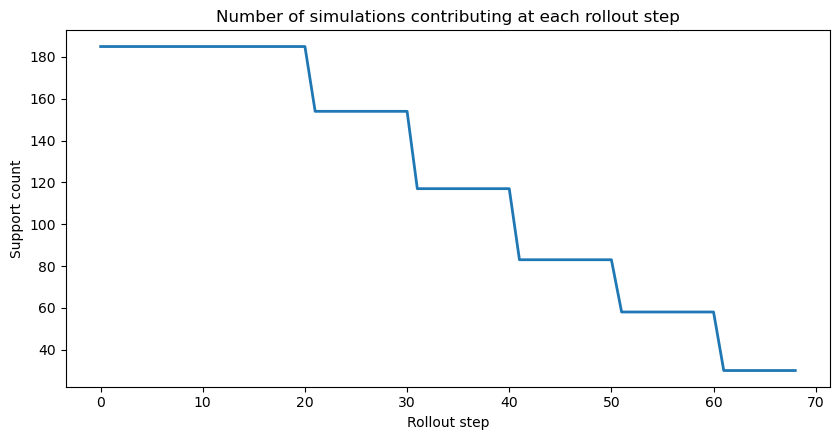

In [84]:
plt.figure(figsize=(8.5, 4.5))
plt.plot(support_t, linewidth=2)
plt.title("Number of simulations contributing at each rollout step")
plt.xlabel("Rollout step")
plt.ylabel("Support count")
plt.tight_layout()
plt.show()

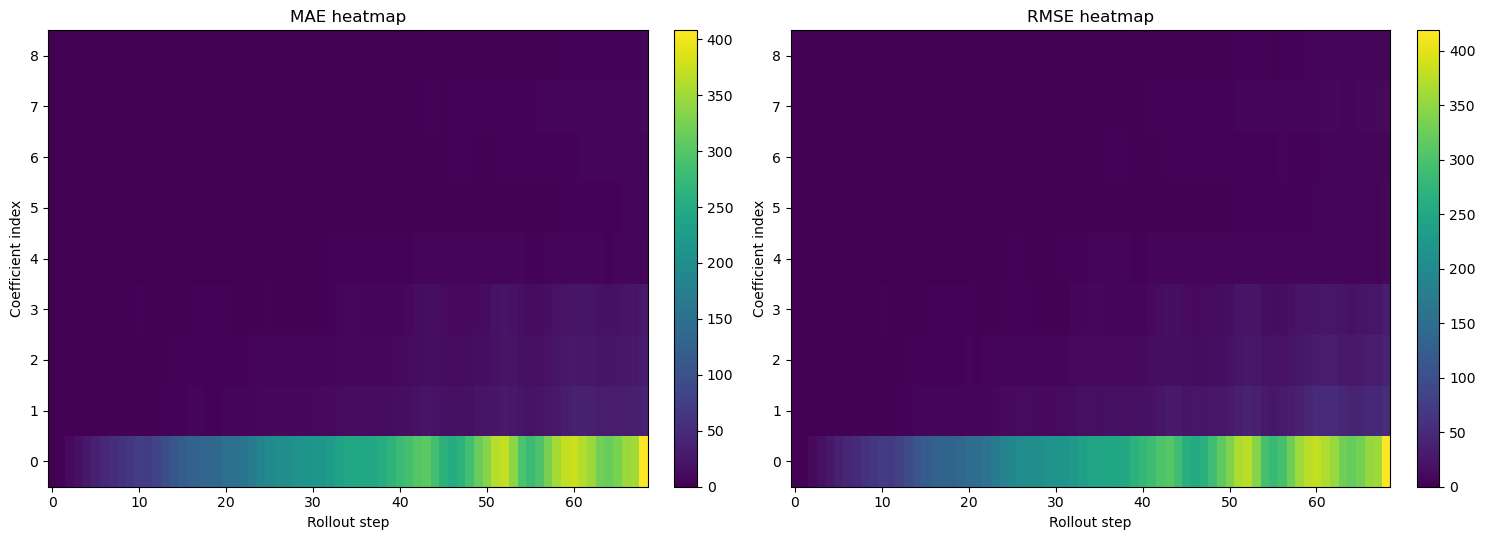

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

im0 = axes[0].imshow(mae_t.T, aspect="auto", origin="lower")
axes[0].set_title("MAE heatmap")
axes[0].set_xlabel("Rollout step")
axes[0].set_ylabel("Coefficient index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(rmse_t.T, aspect="auto", origin="lower")
axes[1].set_title("RMSE heatmap")
axes[1].set_xlabel("Rollout step")
axes[1].set_ylabel("Coefficient index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [86]:
early_end = min(5, max_T)
late_start = max(0, max_T - 5)

early_mae = np.nanmean(mae_t[:early_end], axis=0)
late_mae  = np.nanmean(mae_t[late_start:], axis=0)

growth_df = pd.DataFrame({
    "coef_idx": np.arange(r),
    "early_MAE": early_mae,
    "late_MAE": late_mae,
    "late_minus_early": late_mae - early_mae,
    "late_div_early": late_mae / (early_mae + 1e-12),
}).sort_values("late_minus_early", ascending=False)

display(growth_df)

,coef_idx,early_MAE,late_MAE,late_minus_early,late_div_early
0,0,11.937689,348.646417,336.708728,29.205519
1,1,0.682084,32.898215,32.216132,48.231936
2,2,0.516703,26.618197,26.101494,51.515503
3,3,0.565003,22.125118,21.560115,39.159325
7,7,0.130202,7.020856,6.890654,53.922769
6,6,0.262118,5.374886,5.112768,20.505587
4,4,0.227460,5.307333,5.079873,23.333036
5,5,0.177828,5.228343,5.050515,29.401141
8,8,0.109044,4.361151,4.252108,39.994585


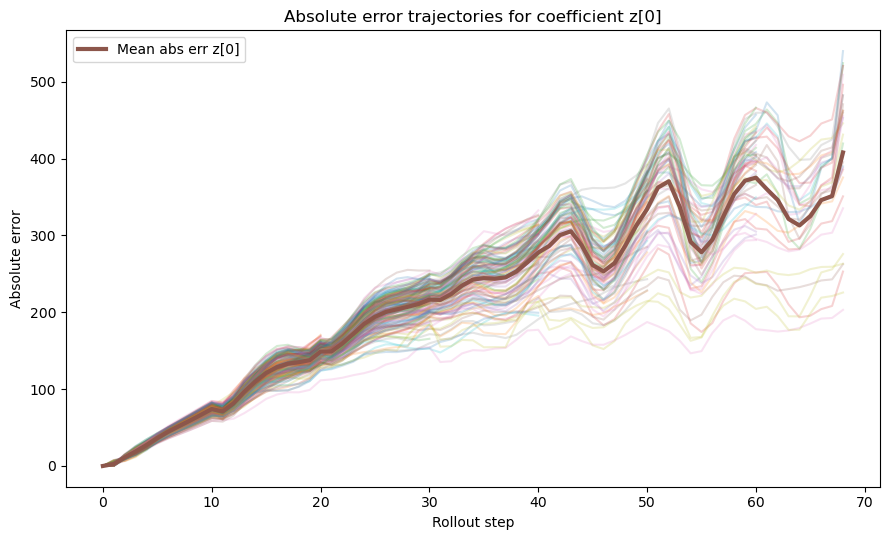

In [87]:
coef_to_plot = 0  # change this

plt.figure(figsize=(9, 5.5))
for rec in records:
    plt.plot(rec["abs_err"][:, coef_to_plot], alpha=0.2)

plt.plot(mae_t[:, coef_to_plot], linewidth=3, label=f"Mean abs err z[{coef_to_plot}]")
plt.title(f"Absolute error trajectories for coefficient z[{coef_to_plot}]")
plt.xlabel("Rollout step")
plt.ylabel("Absolute error")
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
# For each simulation and coefficient:
#   scale_sim[k] = std over time of z_true[:, k]
# Then normalized error = error / scale_sim[k]

EPS = 1e-12

for rec in records:
    true_std_per_coef = np.std(rec["z_true"], axis=0)   # shape (r,)
    rec["true_std_per_coef"] = true_std_per_coef
    rec["norm_err_by_simstd"] = rec["err"] / (true_std_per_coef[None, :] + EPS)
    rec["abs_norm_err_by_simstd"] = np.abs(rec["norm_err_by_simstd"])
    rec["sq_norm_err_by_simstd"] = rec["norm_err_by_simstd"] ** 2

In [89]:
all_norm_err = np.concatenate([rec["norm_err_by_simstd"] for rec in records], axis=0)

coef_metrics_norm_simstd = pd.DataFrame({
    "coef_idx": np.arange(all_norm_err.shape[1]),
    "NormMAE_by_simstd": np.mean(np.abs(all_norm_err), axis=0),
    "NormRMSE_by_simstd": np.sqrt(np.mean(all_norm_err**2, axis=0)),
    "NormBias_by_simstd": np.mean(all_norm_err, axis=0),
    "NormStdErr_by_simstd": np.std(all_norm_err, axis=0),
}).sort_values("NormRMSE_by_simstd", ascending=False)

display(coef_metrics_norm_simstd)

,coef_idx,NormMAE_by_simstd,NormRMSE_by_simstd,NormBias_by_simstd,NormStdErr_by_simstd
6,6,1.097876,2.563387,0.773812,2.443802
4,4,1.100019,1.766251,1.009704,1.449189
7,7,0.705427,1.080403,-0.126553,1.072966
0,0,0.787955,0.930264,-0.787937,0.494515
2,2,0.574294,0.923571,0.337761,0.859594
8,8,0.551847,0.921918,0.252101,0.886781
5,5,0.561747,0.894744,-0.171971,0.878063
3,3,0.440792,0.670013,-0.202840,0.638572
1,1,0.341852,0.548709,0.073225,0.543802


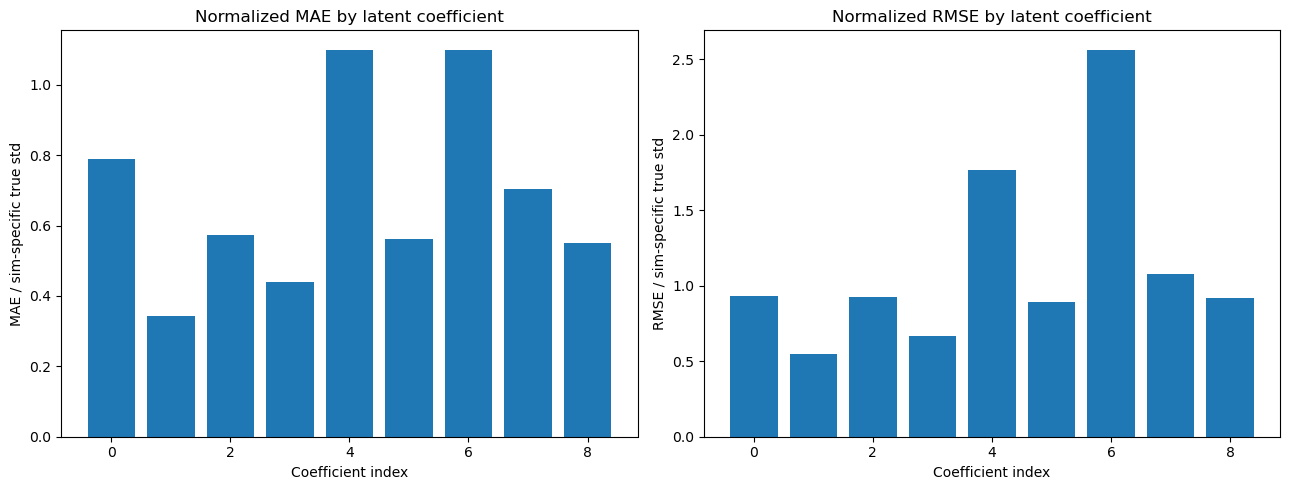

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    coef_metrics_norm_simstd["coef_idx"],
    coef_metrics_norm_simstd["NormMAE_by_simstd"]
)
axes[0].set_title("Normalized MAE by latent coefficient")
axes[0].set_xlabel("Coefficient index")
axes[0].set_ylabel("MAE / sim-specific true std")

axes[1].bar(
    coef_metrics_norm_simstd["coef_idx"],
    coef_metrics_norm_simstd["NormRMSE_by_simstd"]
)
axes[1].set_title("Normalized RMSE by latent coefficient")
axes[1].set_xlabel("Coefficient index")
axes[1].set_ylabel("RMSE / sim-specific true std")

plt.tight_layout()
plt.show()

In [91]:
norm_mae_t = np.full((max_T, r), np.nan)
norm_rmse_t = np.full((max_T, r), np.nan)
norm_bias_t = np.full((max_T, r), np.nan)

for t in range(max_T):
    errs_t = []
    for rec in records:
        if rec["T"] > t:
            errs_t.append(rec["norm_err_by_simstd"][t])

    if len(errs_t) == 0:
        continue

    errs_t = np.stack(errs_t, axis=0)
    norm_mae_t[t] = np.mean(np.abs(errs_t), axis=0)
    norm_rmse_t[t] = np.sqrt(np.mean(errs_t**2, axis=0))
    norm_bias_t[t] = np.mean(errs_t, axis=0)

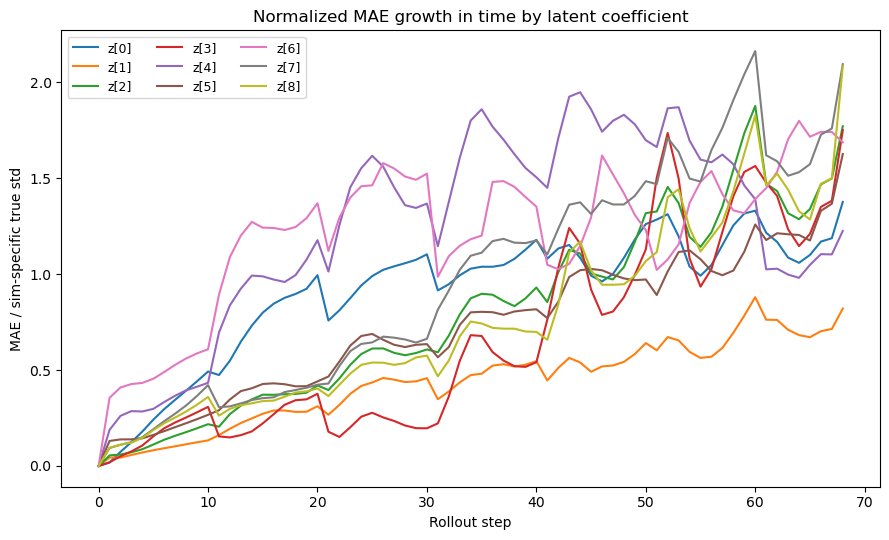

In [92]:
plt.figure(figsize=(9, 5.5))
for k in range(r):
    plt.plot(norm_mae_t[:, k], label=f"z[{k}]")
plt.title("Normalized MAE growth in time by latent coefficient")
plt.xlabel("Rollout step")
plt.ylabel("MAE / sim-specific true std")
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

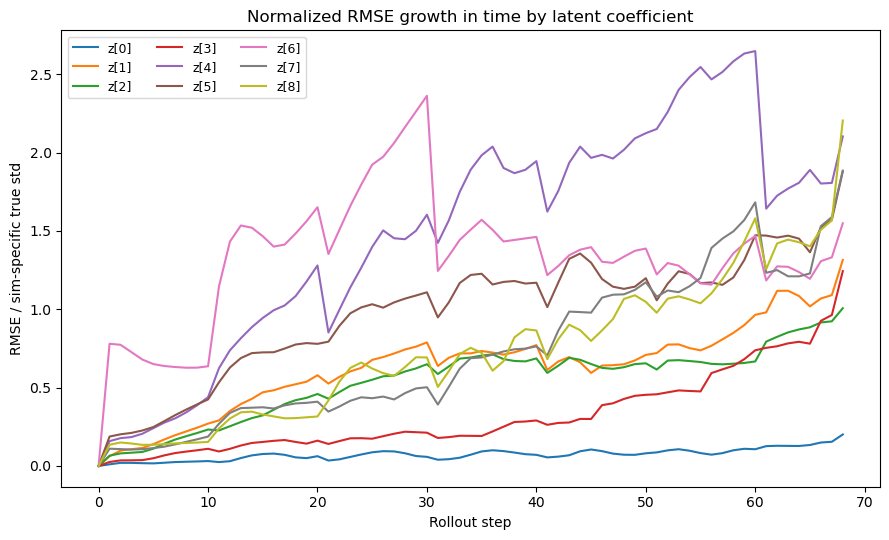

In [62]:
plt.figure(figsize=(9, 5.5))
for k in range(r):
    plt.plot(norm_rmse_t[:, k], label=f"z[{k}]")
plt.title("Normalized RMSE growth in time by latent coefficient")
plt.xlabel("Rollout step")
plt.ylabel("RMSE / sim-specific true std")
plt.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

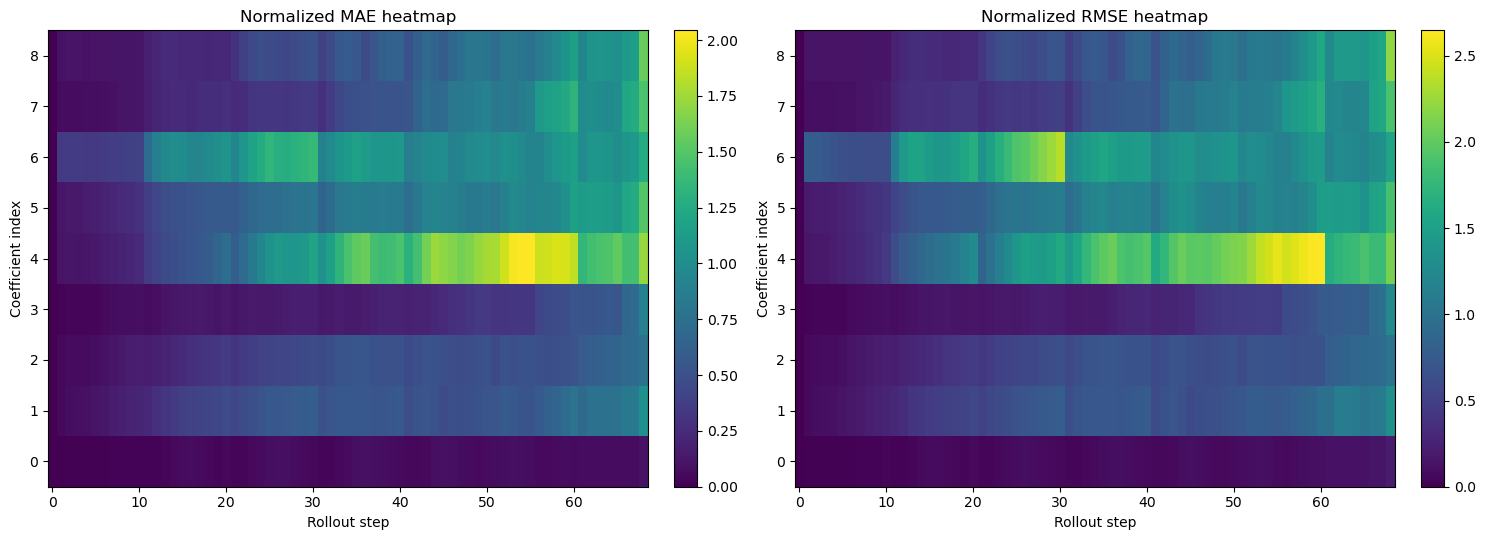

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

im0 = axes[0].imshow(norm_mae_t.T, aspect="auto", origin="lower")
axes[0].set_title("Normalized MAE heatmap")
axes[0].set_xlabel("Rollout step")
axes[0].set_ylabel("Coefficient index")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(norm_rmse_t.T, aspect="auto", origin="lower")
axes[1].set_title("Normalized RMSE heatmap")
axes[1].set_xlabel("Rollout step")
axes[1].set_ylabel("Coefficient index")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()